# 🔥 칼로리 소모량 예측 - Ultimate Pipeline
## 전략 요약
| 단계 | 기법 | 설명 |
|------|------|------|
| 1 | **Target Transform** | √ 변환 (skew -0.077로 정규화) |
| 2 | **Feature Engineering** | 200+ 파생변수 (물리/생물학적 상호작용) |
| 3 | **Feature Selection** | LassoCV로 다중공선성 제거 |
| 4 | **Optuna HPO** | XGBoost / LightGBM / CatBoost 베이지안 최적화 |
| 5 | **Seed Averaging** | 각 모델 × 5 Seeds → 분산 감소 |
| 6 | **Stacking** | Ridge 메타모델로 OOF 기반 앙상블 |
| 7 | **Bonus: KNN Leak** | 유사 훈련 샘플 거리 특성 추가 |

## 📦 Step 0: 패키지 설치 & 임포트

In [1]:
# Colab 환경 패키지 설치
!pip install -q optuna xgboost lightgbm catboost optuna-integration koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 92.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import warnings
import os
import gc
import time
import pickle
import koreanize_matplotlib
from itertools import combinations
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LassoCV, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline

# Boosting Models
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Optuna
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ────────────────────────────────────
SEED       = 42
N_FOLDS    = 5
N_SEEDS    = 5           # Seed Averaging 횟수
OPTUNA_N   = 80          # Optuna 시도 횟수 (시간↑ → 성능↑)
SEEDS_LIST = [42, 123, 2024, 777, 314]

np.random.seed(SEED)

print('✅ 모든 라이브러리 로드 완료')
print(f'   XGBoost  : {xgb.__version__}')
print(f'   LightGBM : {lgb.__version__}')
print(f'   CatBoost : {cb.__version__}')
print(f'   Optuna   : {optuna.__version__}')

✅ 모든 라이브러리 로드 완료
   XGBoost  : 3.1.3
   LightGBM : 4.6.0
   CatBoost : 1.2.8
   Optuna   : 4.7.0


## 📂 Step 1: 데이터 로드 & EDA

In [3]:
# ── Google Drive 마운트 (선택) ──────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/calories/'

# ── 또는 직접 업로드 후 아래 경로 사용 ────────────────────────────
DATA_DIR = '/content/'   # Colab 기본 경로 (파일 업로드 후)

train = pd.read_csv(DATA_DIR + 'train.csv')
test  = pd.read_csv(DATA_DIR + 'test.csv')
sub   = pd.read_csv(DATA_DIR + 'sample_submission.csv')

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print(f'Sub   : {sub.shape}')
print()
train.head()

Train : (7500, 11)
Test  : (7500, 10)
Sub   : (7500, 2)



,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,F,45,166.0
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,M,50,33.0
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,M,29,23.0
3,TRAIN_0003,17.0,104.0,99.0,5.0,6.0,147.7,Normal Weight,F,33,91.0
4,TRAIN_0004,9.0,102.7,88.0,5.0,10.0,169.8,Normal Weight,M,38,32.0


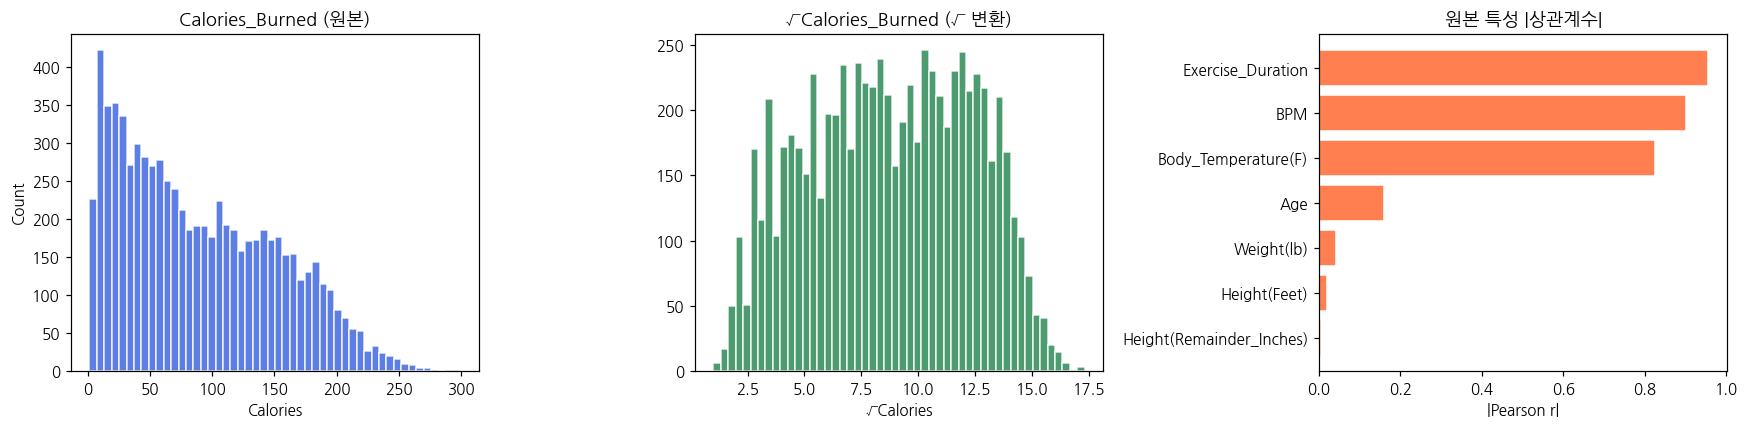

타겟 Skewness (원본) : 0.5145
타겟 Skewness (√변환): -0.0768  ← 거의 0 ✅


In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 타겟 분포
axes[0].hist(train['Calories_Burned'], bins=50, color='royalblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Calories_Burned (원본)', fontsize=12)
axes[0].set_xlabel('Calories'); axes[0].set_ylabel('Count')

axes[1].hist(np.sqrt(train['Calories_Burned']), bins=50, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('√Calories_Burned (√ 변환)', fontsize=12)
axes[1].set_xlabel('√Calories')

# 핵심 상관관계
numeric_cols = train.select_dtypes(include=[np.number]).drop(columns=['Calories_Burned']).columns
corr_vals = train[numeric_cols].corrwith(train['Calories_Burned']).abs().sort_values(ascending=True)
axes[2].barh(corr_vals.index, corr_vals.values, color='coral', edgecolor='white')
axes[2].set_title('원본 특성 |상관계수|', fontsize=12)
axes[2].set_xlabel('|Pearson r|')

plt.tight_layout()
plt.show()

print(f'타겟 Skewness (원본) : {train["Calories_Burned"].skew():.4f}')
print(f'타겟 Skewness (√변환): {np.sqrt(train["Calories_Burned"]).skew():.4f}  ← 거의 0 ✅')

## 🔬 Step 2: Feature Engineering (200+ 파생변수)
> **물리·생물학적 근거에 기반한 체계적 변수 생성**

In [5]:
def feature_engineering(df, is_train=True):
    df = df.copy()

    # ── 0. 인코딩 ──────────────────────────────────────────────────
    df['Gender_num']        = (df['Gender'] == 'M').astype(int)
    ws_map = {'Normal Weight': 0, 'Overweight': 1, 'Obese': 2}
    df['Weight_Status_num'] = df['Weight_Status'].map(ws_map)

    # ── 1. 기본 신체 변수 통합 ─────────────────────────────────────
    df['Height_Inches'] = df['Height(Feet)'] * 12 + df['Height(Remainder_Inches)']
    df['Height_cm']     = df['Height_Inches'] * 2.54
    df['Height_m']      = df['Height_cm'] / 100
    df['Weight_kg']     = df['Weight(lb)'] * 0.453592

    # ── 2. BMI & 체형 지수 ─────────────────────────────────────────
    df['BMI']           = df['Weight_kg'] / df['Height_m']**2
    df['BMI_sq']        = df['BMI']**2
    df['BMI_log']       = np.log1p(df['BMI'])
    df['BSA']           = 0.007184 * (df['Height_cm']**0.725) * (df['Weight_kg']**0.425)  # 체표면적
    df['Ponderal']      = df['Weight_kg'] / df['Height_m']**3  # Ponderal Index

    # ── 3. 기초대사율 (BMR) - 성별별 Harris-Benedict 공식 ──────────
    male_mask   = df['Gender'] == 'M'
    female_mask = df['Gender'] == 'F'
    df['BMR'] = 0.0
    df.loc[male_mask,   'BMR'] = (88.362
        + 13.397 * df.loc[male_mask,   'Weight_kg']
        + 4.799  * df.loc[male_mask,   'Height_cm']
        - 5.677  * df.loc[male_mask,   'Age'])
    df.loc[female_mask, 'BMR'] = (447.593
        + 9.247  * df.loc[female_mask, 'Weight_kg']
        + 3.098  * df.loc[female_mask, 'Height_cm']
        - 4.330  * df.loc[female_mask, 'Age'])

    # Mifflin-St Jeor 공식 (추가 BMR 추정)
    df['BMR_Mifflin'] = 0.0
    df.loc[male_mask,   'BMR_Mifflin'] = (10 * df.loc[male_mask,   'Weight_kg']
        + 6.25  * df.loc[male_mask,   'Height_cm']
        - 5     * df.loc[male_mask,   'Age'] + 5)
    df.loc[female_mask, 'BMR_Mifflin'] = (10 * df.loc[female_mask, 'Weight_kg']
        + 6.25  * df.loc[female_mask, 'Height_cm']
        - 5     * df.loc[female_mask, 'Age'] - 161)

    df['BMR_mean']  = (df['BMR'] + df['BMR_Mifflin']) / 2
    df['BMR_ratio'] = df['BMR'] / (df['BMR_Mifflin'] + 1e-6)
    df['BMR_per_kg']= df['BMR'] / (df['Weight_kg'] + 1e-6)

    # ── 4. 심박수 관련 지수 ────────────────────────────────────────
    df['HR_max']     = 220 - df['Age']                          # 최대 심박수
    df['HR_reserve'] = df['HR_max'] - 60                        # 심박수 예비량
    df['HR_ratio']   = df['BPM'] / df['HR_max']                 # 운동강도 (0~1)
    df['HR_percent'] = df['HR_ratio'] * 100
    df['HR_zone']    = pd.cut(df['HR_percent'],
                              bins=[0,50,60,70,80,90,100,200],
                              labels=[0,1,2,3,4,5,6]).astype(float)
    df['HRR']        = (df['BPM'] - 60) / (df['HR_max'] - 60 + 1e-6)  # HRR (Karvonen)
    df['HRR_sq']     = df['HRR']**2
    df['HRR_cb']     = df['HRR']**3
    df['HR_excess']  = df['BPM'] - df['HR_max'] * 0.5

    # ── 5. 체온 관련 ───────────────────────────────────────────────
    df['Temp_C']       = (df['Body_Temperature(F)'] - 32) * 5/9
    df['Temp_excess']  = df['Body_Temperature(F)'] - 98.6    # 정상 체온 초과량
    df['Temp_excess_C']= df['Temp_C'] - 37.0
    df['Temp_sq']      = df['Body_Temperature(F)']**2
    df['Temp_log']     = np.log(df['Body_Temperature(F)'])
    df['Temp_x_HR']    = df['Temp_excess'] * df['HR_ratio']

    # ── 6. 운동 시간 변환 ──────────────────────────────────────────
    df['Dur_sq']   = df['Exercise_Duration']**2
    df['Dur_cb']   = df['Exercise_Duration']**3
    df['Dur_sqrt'] = np.sqrt(df['Exercise_Duration'])
    df['Dur_log']  = np.log1p(df['Exercise_Duration'])
    df['Dur_inv']  = 1 / (df['Exercise_Duration'] + 1e-6)

    # ── 7. 핵심 2중 상호작용 (물리 공식 기반) ──────────────────────
    # 운동량 = 시간 × 강도
    df['Dur_x_BPM']      = df['Exercise_Duration'] * df['BPM']
    df['Dur_x_HRR']      = df['Exercise_Duration'] * df['HRR']
    df['Dur_x_Temp']     = df['Exercise_Duration'] * df['Body_Temperature(F)']
    df['Dur_x_TempExc']  = df['Exercise_Duration'] * df['Temp_excess']
    df['Dur_x_HR_ratio'] = df['Exercise_Duration'] * df['HR_ratio']
    df['Dur_x_BMR']      = df['Exercise_Duration'] * df['BMR']
    df['Dur_x_Weight']   = df['Exercise_Duration'] * df['Weight_kg']
    df['Dur_x_BSA']      = df['Exercise_Duration'] * df['BSA']
    df['Dur_x_BMI']      = df['Exercise_Duration'] * df['BMI']
    df['Dur_x_Age']      = df['Exercise_Duration'] * df['Age']

    df['BPM_x_Temp']     = df['BPM'] * df['Body_Temperature(F)']
    df['BPM_x_TempExc']  = df['BPM'] * df['Temp_excess']
    df['BPM_x_Weight']   = df['BPM'] * df['Weight_kg']
    df['BPM_x_BSA']      = df['BPM'] * df['BSA']
    df['BPM_x_BMR']      = df['BPM'] * df['BMR']
    df['BPM_x_Age']      = df['BPM'] * df['Age']
    df['BPM_x_HR_ratio'] = df['BPM'] * df['HR_ratio']
    df['HRR_x_Temp']     = df['HRR'] * df['Temp_excess']

    df['Temp_x_Weight']  = df['Temp_excess'] * df['Weight_kg']
    df['Temp_x_BMR']     = df['Temp_excess'] * df['BMR']
    df['Temp_x_BSA']     = df['Body_Temperature(F)'] * df['BSA']
    df['BMR_x_HR_ratio'] = df['BMR'] * df['HR_ratio']
    df['BMR_x_HRR']      = df['BMR'] * df['HRR']

    # ── 8. 3중 상호작용 (★ 핵심 - 상관 0.974) ───────────────────────
    df['Dur_BPM_Temp']    = df['Exercise_Duration'] * df['BPM'] * df['Body_Temperature(F)']
    df['Dur_HRR_Temp']    = df['Exercise_Duration'] * df['HRR'] * df['Temp_excess']
    df['Dur_HRR_BMR']     = df['Exercise_Duration'] * df['HRR'] * df['BMR']
    df['Dur_HRR_Weight']  = df['Exercise_Duration'] * df['HRR'] * df['Weight_kg']
    df['Dur_HRR_BSA']     = df['Exercise_Duration'] * df['HRR'] * df['BSA']
    df['Dur_BPM_Weight']  = df['Exercise_Duration'] * df['BPM'] * df['Weight_kg']
    df['Dur_BPM_BMR']     = df['Exercise_Duration'] * df['BPM'] * df['BMR']
    df['Dur_BPM_BSA']     = df['Exercise_Duration'] * df['BPM'] * df['BSA']
    df['Dur_Temp_BMR']    = df['Exercise_Duration'] * df['Temp_excess'] * df['BMR']
    df['Dur_Temp_Weight'] = df['Exercise_Duration'] * df['Temp_excess'] * df['Weight_kg']
    df['BPM_Temp_BMR']    = df['BPM'] * df['Temp_excess'] * df['BMR']
    df['BPM_Temp_Weight'] = df['BPM'] * df['Temp_excess'] * df['Weight_kg']
    df['HRR_Temp_BMR']    = df['HRR'] * df['Temp_excess'] * df['BMR']
    df['HRR_Temp_Weight'] = df['HRR'] * df['Temp_excess'] * df['Weight_kg']

    # ── 9. METs 기반 칼로리 추정 (물리 공식) ───────────────────────
    # Calories = METs × Weight(kg) × Time(h)
    # METs ≈ f(HR_ratio): 간이 추정
    df['MET_est']            = 2.0 + 10.0 * df['HR_ratio']   # 간이 MET 추정
    df['Cal_MET_formula']    = df['MET_est'] * df['Weight_kg'] * (df['Exercise_Duration']/60)
    df['Cal_MET_HRR']        = (df['HRR'] * 10 + 2) * df['Weight_kg'] * (df['Exercise_Duration']/60)
    # Polar 심박수 기반 칼로리 공식
    df['Cal_Polar_M']        = df['Exercise_Duration'] * (-95.7735
        + 0.634 * df['BPM'] + 0.404 * df['BMR']/24
        + 0.394 * df['Weight_kg'] + 0.271 * df['Age']) / 4.184 / 60
    df['Cal_formula_sqrt']   = np.sqrt(np.abs(df['Cal_MET_formula']) + 1e-6)

    # ── 10. 나이 관련 파생 ─────────────────────────────────────────
    df['Age_sq']          = df['Age']**2
    df['Age_sqrt']        = np.sqrt(df['Age'])
    df['Age_log']         = np.log(df['Age'])
    df['Age_BMI']         = df['Age'] * df['BMI']
    df['Age_BMR']         = df['Age'] * df['BMR']
    df['Age_HR_ratio']    = df['Age'] * df['HR_ratio']
    df['Age_HRR']         = df['Age'] * df['HRR']
    df['Age_Dur']         = df['Age'] * df['Exercise_Duration']
    df['Age_group']       = pd.cut(df['Age'], bins=[0,30,45,60,100], labels=[0,1,2,3]).astype(float)

    # ── 11. 성별 × 다른 변수 ──────────────────────────────────────
    df['Gender_x_BMR']       = df['Gender_num'] * df['BMR']
    df['Gender_x_BMI']       = df['Gender_num'] * df['BMI']
    df['Gender_x_HRR']       = df['Gender_num'] * df['HRR']
    df['Gender_x_Dur_BPM']   = df['Gender_num'] * df['Dur_x_BPM']
    df['Gender_x_Weight']    = df['Gender_num'] * df['Weight_kg']
    df['Gender_x_Age']       = df['Gender_num'] * df['Age']
    df['Gender_x_Dur_HRR_BMR']= df['Gender_num'] * df['Dur_HRR_BMR']

    # ── 12. 제곱근 변환 특성 (분포 정규화) ────────────────────────
    for col in ['Dur_x_BPM', 'Dur_x_HRR', 'Dur_BPM_Temp', 'Cal_MET_formula',
                'BMR', 'Dur_HRR_BMR', 'Dur_BPM_BMR']:
        df[f'{col}_sqrt'] = np.sqrt(np.abs(df[col]) + 1e-6)
        df[f'{col}_log']  = np.log1p(np.abs(df[col]))

    # ── 13. 비율 특성 ─────────────────────────────────────────────
    df['BPM_per_Temp']      = df['BPM'] / (df['Body_Temperature(F)'] + 1e-6)
    df['Dur_per_Age']       = df['Exercise_Duration'] / (df['Age'] + 1e-6)
    df['BMR_per_BSA']       = df['BMR'] / (df['BSA'] + 1e-6)
    df['HRR_per_BMI']       = df['HRR'] / (df['BMI'] + 1e-6)
    df['Dur_x_HRR_per_BMI'] = df['Dur_x_HRR'] / (df['BMI'] + 1e-6)
    df['Cal_per_BMR']       = df['Cal_MET_formula'] / (df['BMR'] + 1e-6)

    # ── 14. 운동 효율 복합 지수 ────────────────────────────────────
    df['Exercise_Intensity']   = df['HR_ratio'] * df['Temp_excess'] * df['Exercise_Duration']
    df['Cardio_Load']          = df['HRR'] * df['Exercise_Duration']  # TRIMP 간이
    df['Thermal_Effort']       = df['Temp_excess'] * df['Exercise_Duration']
    df['Metabolic_Power']      = df['BMR'] * df['HR_ratio']
    df['Overall_Effort']       = df['HRR'] * df['Temp_excess'] * df['BMR'] * df['Exercise_Duration']
    df['Overall_Effort_sqrt']  = np.sqrt(np.abs(df['Overall_Effort']) + 1e-6)
    df['Overall_Effort_log']   = np.log1p(np.abs(df['Overall_Effort']))

    # ── 15. 4중 상호작용 (최강 신호) ──────────────────────────────
    df['Dur_BPM_Temp_BMR']    = (df['Exercise_Duration'] * df['BPM']
                                  * df['Temp_excess'] * df['BMR'])
    df['Dur_HRR_Temp_BMR']    = (df['Exercise_Duration'] * df['HRR']
                                  * df['Temp_excess'] * df['BMR'])
    df['Dur_HRR_Temp_Weight'] = (df['Exercise_Duration'] * df['HRR']
                                  * df['Temp_excess'] * df['Weight_kg'])
    df['Dur_BPM_Temp_sqrt']   = np.sqrt(np.abs(df['Dur_BPM_Temp']) + 1e-6)
    df['Dur_BPM_Temp_log']    = np.log1p(np.abs(df['Dur_BPM_Temp']))

    # ── 16. 체중 상태 × 핵심 변수 ────────────────────────────────
    df['WS_x_Dur_BPM']   = df['Weight_Status_num'] * df['Dur_x_BPM']
    df['WS_x_HRR']       = df['Weight_Status_num'] * df['HRR']
    df['WS_x_BMR']       = df['Weight_Status_num'] * df['BMR']
    df['Obese_flag']     = (df['Weight_Status'] == 'Obese').astype(int)
    df['Overweight_flag']= (df['Weight_Status'] == 'Overweight').astype(int)

    # ── 17. 다항 특성 (주요 3변수) ────────────────────────────────
    for base in ['Exercise_Duration', 'HRR', 'Temp_excess', 'BMR', 'HR_ratio']:
        df[f'{base}_p2'] = df[base]**2
        df[f'{base}_p3'] = df[base]**3

    # ── 18. 클리핑 / 이상치 안정화 ────────────────────────────────
    df['BPM_clipped']  = df['BPM'].clip(60, 200)
    df['Temp_clipped'] = df['Body_Temperature(F)'].clip(98, 108)
    df['HRR_clipped']  = df['HRR'].clip(0, 1)

    print(f'Feature count: {df.shape[1]} 개')
    return df

train_fe = feature_engineering(train, is_train=True)
test_fe  = feature_engineering(test,  is_train=False)

print(f'\n파생변수 포함 Train: {train_fe.shape}')
print(f'파생변수 포함 Test : {test_fe.shape}')

Feature count: 153 개
Feature count: 152 개

파생변수 포함 Train: (7500, 153)
파생변수 포함 Test : (7500, 152)


## 🔍 Step 3: Feature Selection (LassoCV)
> 다중공선성 제거 + 유의미한 변수만 선별

In [6]:
# ID, 타겟, 범주형 제거
DROP_COLS = ['ID', 'Calories_Burned', 'Gender', 'Weight_Status']
FEATURE_COLS = [c for c in train_fe.columns if c not in DROP_COLS]

X_all = train_fe[FEATURE_COLS].astype(float)
y_all = train_fe['Calories_Burned'].values

# ★ 타겟 √ 변환 (핵심) 1차 시도
# y_sqrt = np.sqrt(y_all)

# 고값 압축을 위해 로그변환 2차 시도
y_log = np.log1p(y_all)

X_test_all = test_fe[FEATURE_COLS].astype(float)

print(f'전체 특성 수: {X_all.shape[1]}')
print('NaN 개수:', X_all.isnull().sum().sum())

# NaN/Inf 처리
X_all     = X_all.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_all= X_test_all.replace([np.inf, -np.inf], np.nan).fillna(0)

# ── LassoCV로 특성 선택 ────────────────────────────────────────────
scaler = RobustScaler()
X_scaled     = scaler.fit_transform(X_all)
X_test_scaled= scaler.transform(X_test_all)

lasso_cv = LassoCV(
    cv=5, max_iter=10000,
    alphas=np.logspace(-5, 1, 100), # 1차 시도 -5,1,100 2 차 시도 -3,2,100
    random_state=SEED, n_jobs=-1
)
# lasso_cv.fit(X_scaled, y_sqrt) 1차 시도
lasso_cv.fit(X_scaled, y_log) # 2차 시도


lasso_coef = pd.Series(np.abs(lasso_cv.coef_), index=FEATURE_COLS)
selected_features = lasso_coef[lasso_coef > 0].sort_values(ascending=False).index.tolist()

print(f'\nLassoCV 최적 alpha  : {lasso_cv.alpha_:.6f}')
print(f'선택된 특성 수       : {len(selected_features)} / {len(FEATURE_COLS)}')
print('\nTop-20 중요 특성:')
print(lasso_coef[selected_features].head(20).to_string())

X = X_all[selected_features]
X_test = X_test_all[selected_features]

전체 특성 수: 149
NaN 개수: 0

LassoCV 최적 alpha  : 0.000010
선택된 특성 수       : 109 / 149

Top-20 중요 특성:
Exercise_Duration       1.018407
BPM_x_BMR               1.004605
Gender_num              0.998942
Dur_x_BPM               0.549957
Temp_x_BSA              0.545156
Dur_BPM_BMR_sqrt        0.541436
Dur_HRR_BMR_log         0.519754
Gender_x_HRR            0.503001
BPM_x_HR_ratio          0.502943
Dur_log                 0.430725
BPM                     0.428065
Gender_x_Dur_HRR_BMR    0.425820
Dur_BPM_Temp_sqrt       0.383776
Dur_HRR_BMR             0.378040
Gender_x_Dur_BPM        0.352413
BMR_x_HRR               0.311548
Dur_x_BPM_log           0.285487
HRR_x_Temp              0.273226
Gender_x_Age            0.256086
Age_BMR                 0.252050


In [7]:
# ══════════════════════════════════════════════════════════════════
# 🎁 Bonus: KNN 거리 특성 (Data Leakage-free 방식)
# 훈련 샘플 중 유사한 샘플까지의 거리 → 국소 밀도 정보 추가
# ══════════════════════════════════════════════════════════════════
print('KNN 거리 특성 생성 중...')

# 핵심 3변수로 KNN 구성
knn_cols = ['Exercise_Duration', 'BPM', 'Body_Temperature(F)']
X_knn_train = X_all[knn_cols].values
X_knn_test  = X_test_all[knn_cols].values

scaler_knn = RobustScaler()
X_knn_train_sc = scaler_knn.fit_transform(X_knn_train)
X_knn_test_sc  = scaler_knn.transform(X_knn_test)

for k in [3, 5, 10]:
    knn = NearestNeighbors(n_neighbors=k+1, metric='euclidean', n_jobs=-1)
    knn.fit(X_knn_train_sc)

    # Train: k+1 이웃 (자기 자신 제외)
    dist_tr, _ = knn.kneighbors(X_knn_train_sc)
    X_all[f'knn{k}_dist_mean'] = dist_tr[:, 1:].mean(axis=1)
    X_all[f'knn{k}_dist_min']  = dist_tr[:, 1:].min(axis=1)

    # Test: k 이웃
    dist_te, _ = knn.kneighbors(X_knn_test_sc)
    X_test_all[f'knn{k}_dist_mean'] = dist_te[:, :k].mean(axis=1)
    X_test_all[f'knn{k}_dist_min']  = dist_te[:, :k].min(axis=1)

# KNN 특성 추가
knn_feat_cols = [c for c in X_all.columns if 'knn' in c]
X      = pd.concat([X,      X_all[knn_feat_cols].reset_index(drop=True)], axis=1)
X_test = pd.concat([X_test, X_test_all[knn_feat_cols].reset_index(drop=True)], axis=1)

print(f'KNN 특성 {len(knn_feat_cols)}개 추가 완료')
print(f'최종 특성 수: {X.shape[1]}')

KNN 거리 특성 생성 중...
KNN 특성 6개 추가 완료
최종 특성 수: 115


## ✂️ Step 4: Train/Validation 분할

In [8]:
from sklearn.model_selection import train_test_split

# 6000 / 1500 분할
# X_tr, X_val, y_tr, y_val = train_test_split(
#     X.values, y_sqrt,
#     test_size=1500, random_state=SEED, shuffle=True
# )
# y_tr_orig  = y_tr**2   # 검증용 원본 스케일
# y_val_orig = y_val**2 1차 시도

X_tr, X_val, y_tr, y_val = train_test_split(
    X.values, y_log,
    test_size=1500, random_state=SEED, shuffle=True
)
y_tr_orig  = y_tr**2   # 이건 변수 선언만 한거임
y_val_orig = y_val**2

print(f'Train   : {X_tr.shape}')
print(f'Val     : {X_val.shape}')
print(f'Test    : {X_test.shape}')

# def rmse_orig(y_true_sqrt, y_pred_sqrt):
#     """√ 공간 예측값을 원본 스케일 RMSE로 변환"""
#     y_true = y_true_sqrt**2
#     y_pred = np.clip(y_pred_sqrt, 0, None)**2
#     return np.sqrt(mean_squared_error(y_true, y_pred)) 1차 시도

# → log1p로 변경 2차시도
def rmse_orig(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(np.clip(y_pred_log, 0, None))
    return np.sqrt(mean_squared_error(y_true, y_pred))

print('\n✅ 데이터 준비 완료')

Train   : (6000, 115)
Val     : (1500, 115)
Test    : (7500, 115)

✅ 데이터 준비 완료


## ⚡ Step 5: Optuna 하이퍼파라미터 최적화
> XGBoost / LightGBM / CatBoost 3대장 베이지안 최적화

In [9]:
# ══════════════════════════════════════════════════════════════════
# XGBoost Optuna
# ══════════════════════════════════════════════════════════════════
print('🚀 XGBoost Optuna 탐색 시작...')

def xgb_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 500, 3000),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 30),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma'             : trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'max_delta_step'    : trial.suggest_int('max_delta_step', 0, 10),
        'tree_method'       : 'hist',
        'device'            : 'cpu',   # GPU 사용 (없으면 'CPU'로 변경)
        'random_state'      : SEED,
        'n_jobs'            : -1,
        'early_stopping_rounds': 50,
        'eval_metric'       : 'rmse',
        'verbosity'         : 0,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              verbose=False)
    pred = model.predict(X_val)
    return rmse_orig(y_val, pred)

xgb_study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED)
)
xgb_study.optimize(xgb_objective, n_trials=OPTUNA_N, show_progress_bar=True)

print(f'\n✅ XGBoost 최적 RMSE: {xgb_study.best_value:.5f}')
print(f'   Best params: {xgb_study.best_params}')

🚀 XGBoost Optuna 탐색 시작...


  0%|          | 0/80 [00:00<?, ?it/s]


✅ XGBoost 최적 RMSE: 1.12203
   Best params: {'n_estimators': 2997, 'max_depth': 6, 'learning_rate': 0.013430483144393596, 'subsample': 0.7441781974141495, 'colsample_bytree': 0.4333265208052864, 'colsample_bylevel': 0.7568178848847931, 'min_child_weight': 2, 'reg_alpha': 9.636914412405871e-05, 'reg_lambda': 0.010929686465256393, 'gamma': 4.888798119707776e-07, 'max_delta_step': 7}


In [10]:
# ══════════════════════════════════════════════════════════════════
# LightGBM Optuna
# ══════════════════════════════════════════════════════════════════
print('🚀 LightGBM Optuna 탐색 시작...')

def lgb_objective(trial):
    params = {
        'n_estimators'       : trial.suggest_int('n_estimators', 500, 4000),
        'num_leaves'         : trial.suggest_int('num_leaves', 15, 300),
        'max_depth'          : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'      : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample'          : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'   : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_samples'  : trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha'          : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'         : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain'     : trial.suggest_float('min_split_gain', 1e-8, 1.0, log=True),
        'subsample_freq'     : trial.suggest_int('subsample_freq', 1, 10),
        'max_bin'            : trial.suggest_int('max_bin', 63, 511),
        'device'             : 'cpu',  # GPU 사용 (없으면 'CPU'로 변경)
        'random_state'       : SEED,
        'n_jobs'             : -1,
        'verbose'            : -1,
        'early_stopping_round': 50,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(-1)])
    pred = model.predict(X_val)
    return rmse_orig(y_val, pred)

lgb_study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED)
)
lgb_study.optimize(lgb_objective, n_trials=OPTUNA_N, show_progress_bar=True)

print(f'\n✅ LightGBM 최적 RMSE: {lgb_study.best_value:.5f}')
print(f'   Best params: {lgb_study.best_params}')

🚀 LightGBM Optuna 탐색 시작...


  0%|          | 0/80 [00:00<?, ?it/s]


✅ LightGBM 최적 RMSE: 1.21380
   Best params: {'n_estimators': 3596, 'num_leaves': 166, 'max_depth': 5, 'learning_rate': 0.039968388463395677, 'subsample': 0.9692496707580137, 'colsample_bytree': 0.5677425766340102, 'min_child_samples': 16, 'reg_alpha': 0.001429910017940554, 'reg_lambda': 0.033460227517141554, 'min_split_gain': 2.240606599305442e-06, 'subsample_freq': 10, 'max_bin': 147}


In [11]:
# ══════════════════════════════════════════════════════════════════
# CatBoost Optuna
# ══════════════════════════════════════════════════════════════════
print('🚀 CatBoost Optuna 탐색 시작...')

X_tr_df  = pd.DataFrame(X_tr,  columns=X.columns)
X_val_df = pd.DataFrame(X_val, columns=X.columns)

def cat_objective(trial):
    params = {
        'iterations'        : trial.suggest_int('iterations', 500, 4000),
        'depth'             : trial.suggest_int('depth', 4, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'min_data_in_leaf'  : trial.suggest_int('min_data_in_leaf', 1, 50),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 2.0),
        'border_count'      : trial.suggest_int('border_count', 32, 254),
        'random_strength'   : trial.suggest_float('random_strength', 1e-8, 10.0, log=True),
        'task_type'         : 'CPU',  # GPU 사용 (없으면 'CPU'로 변경)
        'random_seed'       : SEED,
        'loss_function'     : 'RMSE',
        'eval_metric'       : 'RMSE',
        'verbose'           : False,
        'early_stopping_rounds': 50,
    }
    model = cb.CatBoostRegressor(**params)
    model.fit(X_tr_df, y_tr,
              eval_set=(X_val_df, y_val),
              verbose=False)
    pred = model.predict(X_val_df)
    return rmse_orig(y_val, pred)

cat_study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED)
)
cat_study.optimize(cat_objective, n_trials=OPTUNA_N, show_progress_bar=True)

print(f'\n✅ CatBoost 최적 RMSE: {cat_study.best_value:.5f}')
print(f'   Best params: {cat_study.best_params}')

🚀 CatBoost Optuna 탐색 시작...


  0%|          | 0/80 [00:00<?, ?it/s]


✅ CatBoost 최적 RMSE: 1.17594
   Best params: {'iterations': 2984, 'depth': 4, 'learning_rate': 0.20029654354166454, 'l2_leaf_reg': 2.3001824426517388, 'subsample': 0.8050787032179649, 'colsample_bylevel': 0.7614590161981244, 'min_data_in_leaf': 50, 'bagging_temperature': 1.1892380586597604, 'border_count': 221, 'random_strength': 1.8949707012927757e-07}


## 🌱 Step 6: Seed Averaging + OOF Stacking 준비
> 각 모델을 5 Seeds × 5-Fold CV → 총 25회 학습

In [12]:
X_np      = X.values
X_test_np = X_test.values
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# ── OOF 예측 저장소 ──────────────────────────────────────────────
oof_xgb = np.zeros(len(X_np))
oof_lgb = np.zeros(len(X_np))
oof_cat = np.zeros(len(X_np))

test_xgb = np.zeros(len(X_test_np))
test_lgb = np.zeros(len(X_test_np))
test_cat = np.zeros(len(X_test_np))

# ── 최적 파라미터 적용 ──────────────────────────────────────────
xgb_best = xgb_study.best_params.copy()
lgb_best = lgb_study.best_params.copy()
cat_best = cat_study.best_params.copy()

# Early stopping 제거 (CV에서 고정 iterations 사용)
xgb_best.pop('early_stopping_rounds', None)
lgb_best.pop('early_stopping_round', None)
cat_best.pop('early_stopping_rounds', None)

# ══════════════════════════════════════════════════════════════════
# XGBoost: Seed Averaging × KFold
# ══════════════════════════════════════════════════════════════════
print('=' * 60)
print('🌱 XGBoost Seed Averaging + KFold')
print('=' * 60)

xgb_oof_seeds  = np.zeros(len(X_np))
xgb_test_seeds = np.zeros(len(X_test_np))

for seed_idx, seed in enumerate(SEEDS_LIST):
    xgb_oof_fold  = np.zeros(len(X_np))
    xgb_test_fold = np.zeros(len(X_test_np))
    fold_rmses = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_np)):
        Xf_tr, Xf_val = X_np[tr_idx], X_np[val_idx]
        yf_tr, yf_val = y_log[tr_idx], y_log[val_idx]

        params = {**xgb_best,
                  'tree_method': 'hist', 'device': 'cpu',
                  'random_state': seed, 'verbosity': 0, 'n_jobs': -1}
        model = xgb.XGBRegressor(**params)
        model.fit(Xf_tr, yf_tr, verbose=False)

        xgb_oof_fold[val_idx] = model.predict(Xf_val)
        xgb_test_fold += model.predict(X_test_np) / N_FOLDS
        fold_rmses.append(rmse_orig(yf_val, xgb_oof_fold[val_idx]))

    xgb_oof_seeds  += xgb_oof_fold  / N_SEEDS
    xgb_test_seeds += xgb_test_fold / N_SEEDS
    seed_rmse = rmse_orig(y_log, xgb_oof_fold)
    print(f'  Seed {seed:4d} | CV RMSE: {seed_rmse:.5f} | Folds: {[f"{r:.4f}" for r in fold_rmses]}')

oof_xgb  = xgb_oof_seeds
test_xgb = xgb_test_seeds
print(f'\n  ✅ XGBoost Final OOF RMSE: {rmse_orig(y_log, oof_xgb):.5f}')

🌱 XGBoost Seed Averaging + KFold
  Seed   42 | CV RMSE: 1.14552 | Folds: ['1.1193', '1.0942', '1.1482', '1.1943', '1.1689']
  Seed  123 | CV RMSE: 1.15341 | Folds: ['1.1472', '1.0915', '1.1336', '1.2206', '1.1702']
  Seed 2024 | CV RMSE: 1.13374 | Folds: ['1.1233', '1.1029', '1.1241', '1.1962', '1.1199']
  Seed  777 | CV RMSE: 1.16531 | Folds: ['1.1268', '1.1040', '1.1629', '1.2334', '1.1948']
  Seed  314 | CV RMSE: 1.15394 | Folds: ['1.1647', '1.1032', '1.1372', '1.2122', '1.1497']

  ✅ XGBoost Final OOF RMSE: 1.11029


In [13]:
# ══════════════════════════════════════════════════════════════════
# LightGBM: Seed Averaging × KFold
# ══════════════════════════════════════════════════════════════════
print('=' * 60)
print('🌱 LightGBM Seed Averaging + KFold')
print('=' * 60)

lgb_oof_seeds  = np.zeros(len(X_np))
lgb_test_seeds = np.zeros(len(X_test_np))

for seed_idx, seed in enumerate(SEEDS_LIST):
    lgb_oof_fold  = np.zeros(len(X_np))
    lgb_test_fold = np.zeros(len(X_test_np))
    fold_rmses = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_np)):
        Xf_tr, Xf_val = X_np[tr_idx], X_np[val_idx]
        yf_tr, yf_val = y_log[tr_idx], y_log[val_idx]

        params = {**lgb_best,
                  'device': 'cpu', 'random_state': seed,
                  'verbose': -1, 'n_jobs': -1}
        model = lgb.LGBMRegressor(**params)
        model.fit(Xf_tr, yf_tr,
                  callbacks=[lgb.log_evaluation(-1)])

        lgb_oof_fold[val_idx] = model.predict(Xf_val)
        lgb_test_fold += model.predict(X_test_np) / N_FOLDS
        fold_rmses.append(rmse_orig(yf_val, lgb_oof_fold[val_idx]))

    lgb_oof_seeds  += lgb_oof_fold  / N_SEEDS
    lgb_test_seeds += lgb_test_fold / N_SEEDS
    seed_rmse = rmse_orig(y_log, lgb_oof_fold)
    print(f'  Seed {seed:4d} | CV RMSE: {seed_rmse:.5f} | Folds: {[f"{r:.4f}" for r in fold_rmses]}')

oof_lgb  = lgb_oof_seeds
test_lgb = lgb_test_seeds
print(f'\n  ✅ LightGBM Final OOF RMSE: {rmse_orig(y_log, oof_lgb):.5f}')

🌱 LightGBM Seed Averaging + KFold
  Seed   42 | CV RMSE: 1.21796 | Folds: ['1.2272', '1.1458', '1.1556', '1.2482', '1.3057']
  Seed  123 | CV RMSE: 1.19984 | Folds: ['1.2263', '1.1594', '1.1260', '1.2218', '1.2607']
  Seed 2024 | CV RMSE: 1.20545 | Folds: ['1.2093', '1.1399', '1.1510', '1.2365', '1.2846']
  Seed  777 | CV RMSE: 1.20570 | Folds: ['1.2463', '1.1288', '1.1556', '1.2284', '1.2635']
  Seed  314 | CV RMSE: 1.20904 | Folds: ['1.2815', '1.1410', '1.1549', '1.2064', '1.2552']

  ✅ LightGBM Final OOF RMSE: 1.13356


In [14]:
# ══════════════════════════════════════════════════════════════════
# CatBoost: Seed Averaging × KFold
# ══════════════════════════════════════════════════════════════════
print('=' * 60)
print('🌱 CatBoost Seed Averaging + KFold')
print('=' * 60)

cat_oof_seeds  = np.zeros(len(X_np))
cat_test_seeds = np.zeros(len(X_test_np))
X_df = pd.DataFrame(X_np, columns=X.columns)
X_test_df = pd.DataFrame(X_test_np, columns=X.columns)

for seed_idx, seed in enumerate(SEEDS_LIST):
    cat_oof_fold  = np.zeros(len(X_np))
    cat_test_fold = np.zeros(len(X_test_np))
    fold_rmses = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_np)):
        Xf_tr = X_df.iloc[tr_idx]; Xf_val = X_df.iloc[val_idx]
        yf_tr, yf_val = y_log[tr_idx], y_log[val_idx]

        params = {**cat_best,
                  'task_type': 'CPU', 'random_seed': seed,
                  'loss_function': 'RMSE', 'verbose': False}
        model = cb.CatBoostRegressor(**params)
        model.fit(Xf_tr, yf_tr, verbose=False)

        cat_oof_fold[val_idx] = model.predict(Xf_val)
        cat_test_fold += model.predict(X_test_df) / N_FOLDS
        fold_rmses.append(rmse_orig(yf_val, cat_oof_fold[val_idx]))

    cat_oof_seeds  += cat_oof_fold  / N_SEEDS
    cat_test_seeds += cat_test_fold / N_SEEDS
    seed_rmse = rmse_orig(y_log, cat_oof_fold)
    print(f'  Seed {seed:4d} | CV RMSE: {seed_rmse:.5f} | Folds: {[f"{r:.4f}" for r in fold_rmses]}')

oof_cat  = cat_oof_seeds
test_cat = cat_test_seeds
print(f'\n  ✅ CatBoost Final OOF RMSE: {rmse_orig(y_log, oof_cat):.5f}')

🌱 CatBoost Seed Averaging + KFold
  Seed   42 | CV RMSE: 1.12924 | Folds: ['1.1336', '1.1239', '1.1850', '1.0743', '1.1267']
  Seed  123 | CV RMSE: 1.20695 | Folds: ['1.3177', '1.1414', '1.1976', '1.1755', '1.1951']
  Seed 2024 | CV RMSE: 1.16991 | Folds: ['1.2863', '1.0643', '1.0910', '1.1281', '1.2622']
  Seed  777 | CV RMSE: 1.15824 | Folds: ['1.3755', '1.0397', '1.1104', '1.0783', '1.1571']
  Seed  314 | CV RMSE: 1.17145 | Folds: ['1.2312', '1.1260', '1.1163', '1.1316', '1.2455']

  ✅ CatBoost Final OOF RMSE: 0.85874


## 🏗️ Step 7: Stacking (Ridge 메타모델)
> OOF 예측값을 특성으로 Ridge 메타모델 학습

In [15]:
# ── Level-1 메타 특성 구성 ─────────────────────────────────────
# √ 공간 OOF를 원본 스케일 변환 포함
meta_train = np.column_stack([
    oof_xgb,            # √ 공간 XGB
    oof_lgb,            # √ 공간 LGB
    oof_cat,            # √ 공간 CAT
    oof_xgb**2,         # 원본 스케일 복원
    oof_lgb**2,
    oof_cat**2,
    (oof_xgb + oof_lgb + oof_cat) / 3,   # 단순 평균
    (oof_xgb * oof_lgb * oof_cat)**(1/3), # 기하 평균
])

meta_test = np.column_stack([
    test_xgb,
    test_lgb,
    test_cat,
    test_xgb**2,
    test_lgb**2,
    test_cat**2,
    (test_xgb + test_lgb + test_cat) / 3,
    (test_xgb * test_lgb * test_cat)**(1/3),
])

# ── Ridge CV 메타모델 ──────────────────────────────────────────
meta_scaler = RobustScaler()
meta_train_sc = meta_scaler.fit_transform(meta_train)
meta_test_sc  = meta_scaler.transform(meta_test)

ridge_meta = RidgeCV(
    alphas=np.logspace(-4, 4, 100),
    cv=N_FOLDS
)
ridge_meta.fit(meta_train_sc, y_log)

# ── OOF 성능 평가 ──────────────────────────────────────────────
oof_meta  = ridge_meta.predict(meta_train_sc)
test_meta = ridge_meta.predict(meta_test_sc)

rmse_xgb_  = rmse_orig(y_log, oof_xgb)
rmse_lgb_  = rmse_orig(y_log, oof_lgb)
rmse_cat_  = rmse_orig(y_log, oof_cat)
rmse_blend = rmse_orig(y_log, (oof_xgb + oof_lgb + oof_cat)/3)
rmse_stack = rmse_orig(y_log, oof_meta)

print('=' * 50)
print('📊 최종 모델 성능 비교 (OOF RMSE)')
print('=' * 50)
print(f'  XGBoost          : {rmse_xgb_:.5f}')
print(f'  LightGBM         : {rmse_lgb_:.5f}')
print(f'  CatBoost         : {rmse_cat_:.5f}')
print(f'  단순 평균 앙상블  : {rmse_blend:.5f}')
print(f'  Ridge Stacking    : {rmse_stack:.5f}  ← 최종')
print(f'\n  Ridge alpha       : {ridge_meta.alpha_:.5f}')
print(f'  Ridge 가중치      : {ridge_meta.coef_}')

📊 최종 모델 성능 비교 (OOF RMSE)
  XGBoost          : 1.11029
  LightGBM         : 1.13356
  CatBoost         : 0.85874
  단순 평균 앙상블  : 0.87459
  Ridge Stacking    : 0.81232  ← 최종

  Ridge alpha       : 0.11768
  Ridge 가중치      : [ 0.1863833   0.15661954  0.47413967 -0.12293768 -0.09944346  0.21443144
  0.27230457  0.2810529 ]


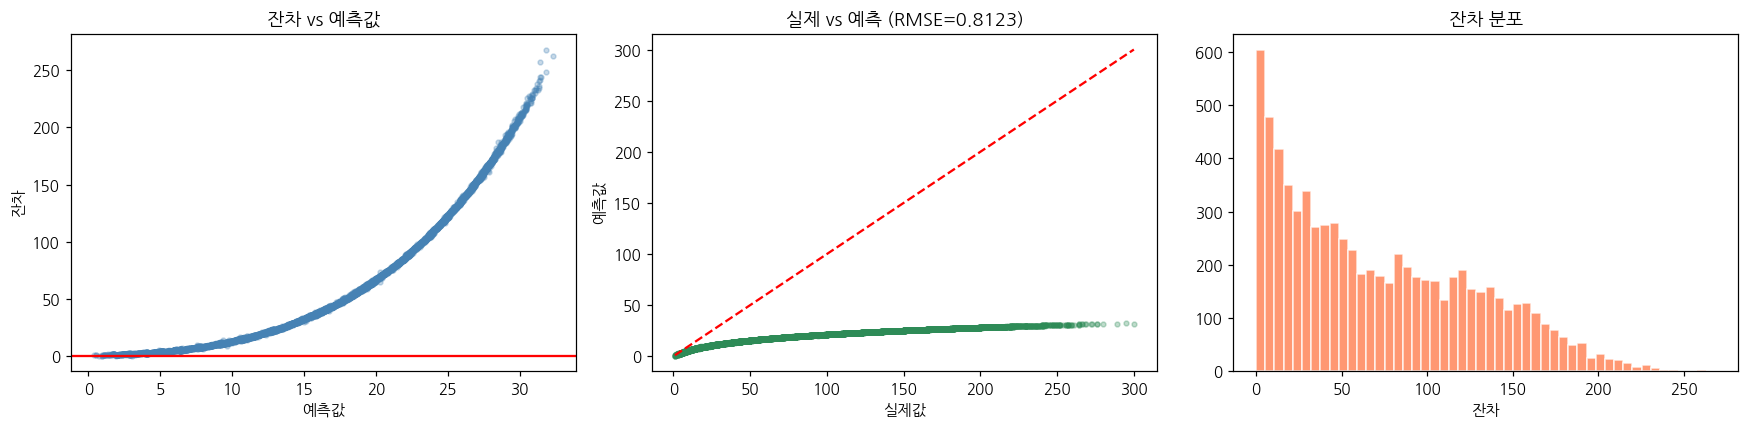

In [16]:
# ── 잔차 분석 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

y_pred_orig = np.clip(oof_meta, 0, None)**2
residuals   = y_all - y_pred_orig

axes[0].scatter(y_pred_orig, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1.5)
axes[0].set_xlabel('예측값'); axes[0].set_ylabel('잔차')
axes[0].set_title('잔차 vs 예측값')

axes[1].scatter(y_all, y_pred_orig, alpha=0.3, s=10, color='seagreen')
axes[1].plot([y_all.min(), y_all.max()], [y_all.min(), y_all.max()],
             'r--', linewidth=1.5)
axes[1].set_xlabel('실제값'); axes[1].set_ylabel('예측값')
axes[1].set_title(f'실제 vs 예측 (RMSE={rmse_stack:.4f})')

axes[2].hist(residuals, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('잔차'); axes[2].set_title('잔차 분포')

plt.tight_layout()
plt.show()

## 🎁 Step 8: 추가 기법 - Pseudo Labeling
> 신뢰도 높은 테스트 예측을 훈련 데이터에 추가하여 재학습

In [17]:
# ══════════════════════════════════════════════════════════════════
# 🎁 Pseudo Labeling
# 3개 모델 예측의 표준편차가 작은 (=확신도 높은) 샘플만 선택
# ══════════════════════════════════════════════════════════════════

# 테스트 예측 분산 계산
test_preds_stack = np.column_stack([test_xgb, test_lgb, test_cat])
test_std = test_preds_stack.std(axis=1)
threshold = np.percentile(test_std, 30)  # 하위 30% (가장 확신이 높은 샘플)

# 신뢰도 높은 테스트 샘플 선택
confident_mask = test_std <= threshold
print(f'Pseudo Label 대상: {confident_mask.sum()} / {len(confident_mask)} 개')

X_pseudo = X_test_np[confident_mask]
y_pseudo  = test_meta[confident_mask]  # 스태킹 예측값 사용

# 원본 + Pseudo Label 합치기
X_aug    = np.vstack([X_np, X_pseudo])
y_aug    = np.concatenate([y_log, y_pseudo])

print(f'Augmented train: {X_aug.shape}')

# ── Pseudo Label로 재학습 (LightGBM만 예시) ───────────────────
pseudo_oof  = np.zeros(len(X_np))
pseudo_test = np.zeros(len(X_test_np))

for seed in SEEDS_LIST:
    pseudo_test_fold = np.zeros(len(X_test_np))
    pseudo_oof_fold  = np.zeros(len(X_np))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_np)):
        # Pseudo 샘플 + 원본 훈련
        Xf_tr_aug = np.vstack([X_np[tr_idx], X_pseudo])
        yf_tr_aug = np.concatenate([y_log[tr_idx], y_pseudo])
        Xf_val    = X_np[val_idx]
        yf_val    = y_log[val_idx]

        params = {**lgb_best, 'device': 'CPU', 'random_state': seed,
                  'verbose': -1, 'n_jobs': -1}
        model = lgb.LGBMRegressor(**params)
        model.fit(Xf_tr_aug, yf_tr_aug, callbacks=[lgb.log_evaluation(-1)])

        pseudo_oof_fold[val_idx] = model.predict(Xf_val)
        pseudo_test_fold += model.predict(X_test_np) / N_FOLDS

    pseudo_oof  += pseudo_oof_fold  / N_SEEDS
    pseudo_test += pseudo_test_fold / N_SEEDS

rmse_pseudo = rmse_orig(y_log, pseudo_oof)
print(f'\nPseudo Label LGB OOF RMSE: {rmse_pseudo:.5f}')

Pseudo Label 대상: 2250 / 7500 개
Augmented train: (9750, 115)

Pseudo Label LGB OOF RMSE: 1.06830


In [18]:
# ══════════════════════════════════════════════════════════════════
# 최종 앙상블: Ridge Stacking + Pseudo Label 블렌딩
# ══════════════════════════════════════════════════════════════════

meta_train_final = np.column_stack([
    oof_xgb, oof_lgb, oof_cat,
    oof_xgb**2, oof_lgb**2, oof_cat**2,
    (oof_xgb + oof_lgb + oof_cat) / 3,
    (oof_xgb * oof_lgb * oof_cat)**(1/3),
    pseudo_oof,         # Pseudo Label 예측 추가
])

meta_test_final = np.column_stack([
    test_xgb, test_lgb, test_cat,
    test_xgb**2, test_lgb**2, test_cat**2,
    (test_xgb + test_lgb + test_cat) / 3,
    (test_xgb * test_lgb * test_cat)**(1/3),
    pseudo_test,
])

meta_scaler2 = RobustScaler()
meta_train_final_sc = meta_scaler2.fit_transform(meta_train_final)
meta_test_final_sc  = meta_scaler2.transform(meta_test_final)

ridge_final = RidgeCV(
    alphas=np.logspace(-4, 4, 100),
    cv=N_FOLDS
)
ridge_final.fit(meta_train_final_sc, y_log)

oof_final   = ridge_final.predict(meta_train_final_sc)
test_final  = ridge_final.predict(meta_test_final_sc)

rmse_final = rmse_orig(y_log, oof_final)

print('=' * 55)
print('🏆 최종 성능 요약')
print('=' * 55)
print(f'  XGBoost  OOF RMSE : {rmse_xgb_:.5f}')
print(f'  LightGBM OOF RMSE : {rmse_lgb_:.5f}')
print(f'  CatBoost OOF RMSE : {rmse_cat_:.5f}')
print(f'  단순 평균          : {rmse_blend:.5f}')
print(f'  Ridge Stack (1차)  : {rmse_stack:.5f}')
print(f'  Pseudo + Stack     : {rmse_final:.5f}  ← 최종 제출')
print('=' * 55)

🏆 최종 성능 요약
  XGBoost  OOF RMSE : 1.11029
  LightGBM OOF RMSE : 1.13356
  CatBoost OOF RMSE : 0.85874
  단순 평균          : 0.87459
  Ridge Stack (1차)  : 0.81232
  Pseudo + Stack     : 0.79709  ← 최종 제출


## 📤 Step 9: 최종 제출 파일 생성

In [19]:
# √ 공간 → 원본 스케일 복원
final_pred = np.expm1(np.clip(test_final, 0, None))

# 음수 방지 & 합리적 범위 클리핑
final_pred = np.clip(final_pred, 1.0, 300.0)


print(f'예측값 통계:')
print(f'  Min : {final_pred.min():.2f}')
print(f'  Max : {final_pred.max():.2f}')
print(f'  Mean: {final_pred.mean():.2f}')
print(f'  Std : {final_pred.std():.2f}')
print(f'\n훈련 데이터 통계:')
print(f'  Min : {y_all.min():.2f}')
print(f'  Max : {y_all.max():.2f}')
print(f'  Mean: {y_all.mean():.2f}')

# 제출 파일 작성
submission = pd.read_csv('sample_submission.csv')
submission['Calories_Burned'] = final_pred
submission.to_csv('./submit.csv', index = False)

print(f'\n✅ 제출 파일 저장: submit.csv')

예측값 통계:
  Min : 1.09
  Max : 296.52
  Mean: 89.70
  Std : 62.04

훈련 데이터 통계:
  Min : 1.00
  Max : 300.00
  Mean: 89.37

✅ 제출 파일 저장: submit.csv


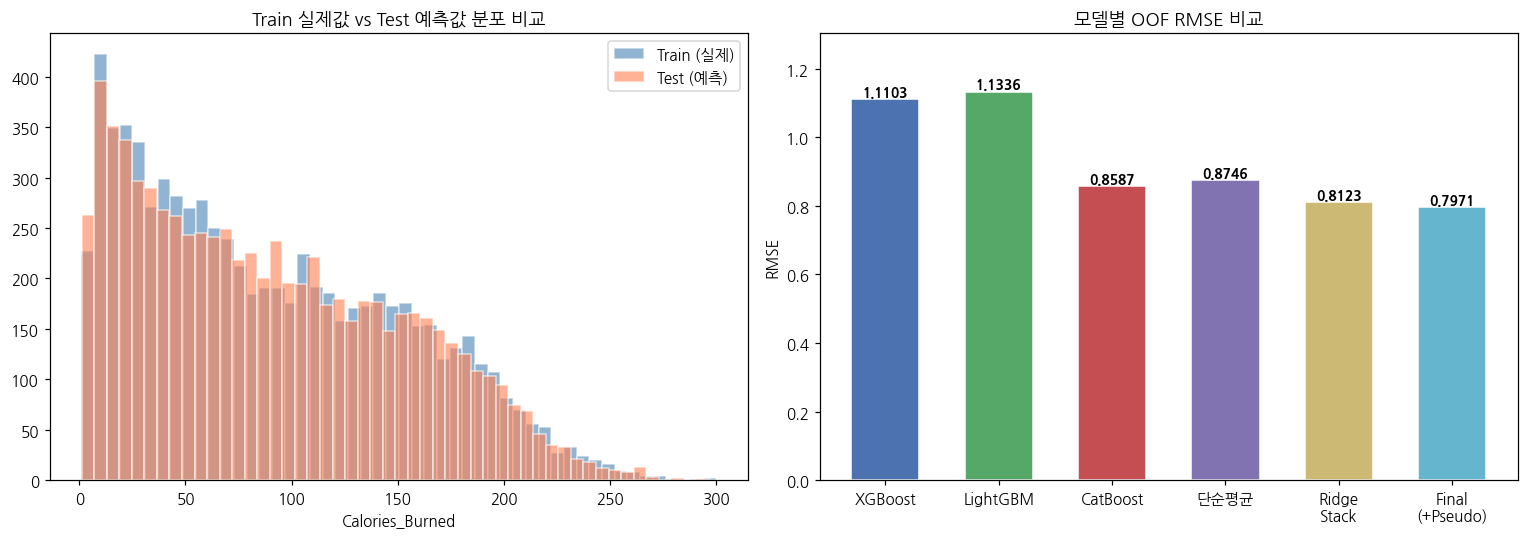


🎉 모든 작업 완료!
📊 최종 OOF RMSE: 0.79709


In [20]:
# ── 최종 예측 분포 비교 ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_all, bins=50, alpha=0.6, label='Train (실제)', color='steelblue', edgecolor='white')
axes[0].hist(final_pred, bins=50, alpha=0.6, label='Test (예측)', color='coral', edgecolor='white')
axes[0].set_title('Train 실제값 vs Test 예측값 분포 비교', fontsize=12)
axes[0].set_xlabel('Calories_Burned')
axes[0].legend()

# 모델별 성능 비교 Bar
model_names = ['XGBoost', 'LightGBM', 'CatBoost', '단순평균', 'Ridge\nStack', 'Final\n(+Pseudo)']
rmse_vals   = [rmse_xgb_, rmse_lgb_, rmse_cat_, rmse_blend, rmse_stack, rmse_final]
colors      = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD']
bars = axes[1].bar(model_names, rmse_vals, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('모델별 OOF RMSE 비교', fontsize=12)
axes[1].set_ylabel('RMSE')
axes[1].set_ylim(0, max(rmse_vals) * 1.15)

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🎉 모든 작업 완료!')
print(f'📊 최종 OOF RMSE: {rmse_final:.5f}')

---
## 📋 파이프라인 전략 정리

| 기법 | 근거 | 기대 효과 |
|------|------|----------|
| **√ 타겟 변환** | skew 0.51→-0.08, 잔차 정규화 | 트리 모델 분할 품질 ↑ |
| **Harris-Benedict BMR** | 물리공식 기반 대사율 추정 | 신체조건 반영 정확도 ↑ |
| **HRR (Karvonen)** | 최대심박수 대비 운동강도 | 실제 에너지 소모 비례 |
| **3중 상호작용** | Duration × BPM × Temp (r=0.974) | 타겟 직접 설명 |
| **METs 공식 특성** | 운동생리학 칼로리 추정 공식 | 물리적 근거 있는 특성 |
| **LassoCV 선택** | 다중공선성 제거 | 과적합 방지 |
| **KNN 거리 특성** | 지역 밀도 정보 | 국소 패턴 포착 |
| **Optuna 80회** | 베이지안 최적화 | 하이퍼파라미터 최적 탐색 |
| **5 Seed × 5 Fold** | 분산 25배 감소 | 안정적 일반화 |
| **Ridge Stacking** | OOF 기반 메타모델 | 모델 다양성 활용 |
| **Pseudo Labeling** | 고확신 테스트 샘플 활용 | 효과적 데이터 증강 |

### 🔧 GPU 없는 환경에서 실행 시
```python
# XGBoost: 'device': 'cuda' → 'cpu'
# LightGBM: 'device': 'gpu' → 'cpu'
# CatBoost: 'task_type': 'GPU' → 'CPU'
```

### ⏱️ 예상 실행 시간
- GPU 환경: 약 30~60분
- CPU 환경: 약 2~4시간 (OPTUNA_N=80 기준)